# Fake News Detection — Bag of Words & TF-IDF (Complete & Corrected)

**What this notebook covers:**
1. Install dependencies & imports
2. Load & explore data (EDA)
3. Preprocessing — correct order, lemmatization only (no stemming)
4. Stratified train / val / test split **before** any vectorisation
5. Feature extraction — BoW and TF-IDF fitted **only on train** (no leakage)
6. Train three classifiers — Logistic Regression, SVM, Naive Bayes
7. Hyperparameter tuning with GridSearchCV
8. Full evaluation — F1, precision, recall, AUC-ROC, MCC, confusion matrix
9. Feature importance — top discriminative words per class
10. Model comparison summary
11. Save best model + vectorizer
12. Inference function

> **Dataset:** `Fake.csv` + `True.csv` (ISOT Fake News dataset)  
> Each file must have at least a `text` column.

---
**Key fixes over a naive approach:**
- Vectorizers are `fit` only on training data, then `transform` on val/test — prevents data leakage
- Lemmatization only (spaCy) — stemming is removed
- Stopwords removed only for BoW/TF-IDF (appropriate for sparse representations)
- Proper 80/10/10 stratified split
- Both BoW and TF-IDF compared head-to-head across all classifiers

## 1. Install Dependencies

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn spacy wordcloud
!python -m spacy download en_core_web_sm -q

import sys
print("Python:", sys.version)

import sklearn
print("scikit-learn:", sklearn.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 81.4 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.1


## 2. Imports

In [2]:
import re
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from wordcloud import WordCloud

# Preprocessing
import spacy
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

# Feature extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.calibration import CalibratedClassifierCV

# Tuning & evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, matthews_corrcoef, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load spaCy — disable unneeded components for speed
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
STOP_WORDS = set(stopwords.words('english'))

print('All imports successful.')

All imports successful.


## 3. Load Data

In [3]:

MODEL_SAVE_DIR = '/kaggle/working/classical_models/'


import os
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── Load CSVs ────────────────────────────────────────────────────────────────
fake_df = pd.read_csv('/kaggle/input/datasets/shibuji/fakenewsdetection/Fake.csv')
true_df = pd.read_csv('/kaggle/input/datasets/shibuji/fakenewsdetection/True.csv')

fake_df['label'] = 0   # 0 = Fake
true_df['label'] = 1   # 1 = Real

df_raw = pd.concat([fake_df, true_df], ignore_index=True)

print(f"Fake articles : {len(fake_df):,}")
print(f"Real articles : {len(true_df):,}")
print(f"Total         : {len(df_raw):,}")
print("\nColumns:", df_raw.columns.tolist())
df_raw.head(3)

Fake articles : 23,481
Real articles : 21,417
Total         : 44,898

Columns: ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0


## 4. Exploratory Data Analysis

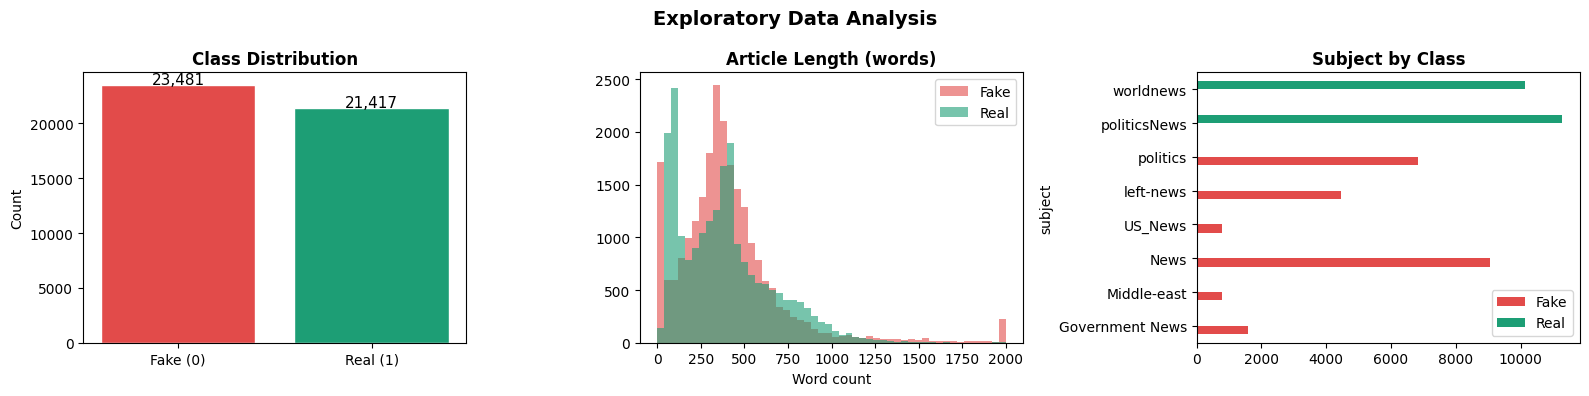


Word count statistics:
         count   mean    std  min    25%    50%    75%     max
label                                                         
Fake   23481.0  423.2  408.4  0.0  240.0  363.0  506.0  8135.0
Real   21417.0  385.6  274.0  0.0  148.0  359.0  525.0  5172.0


In [4]:
# ── Class balance ─────────────────────────────────────────────────────────────
df_raw['word_count'] = df_raw['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
counts = df_raw['label'].value_counts().sort_index()
bars = axes[0].bar(['Fake (0)', 'Real (1)'], counts, color=['#E24B4A', '#1D9E75'], edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=11)

# Article length by class
for label, color, name in [(0, '#E24B4A', 'Fake'), (1, '#1D9E75', 'Real')]:
    wc = df_raw[df_raw['label'] == label]['word_count']
    axes[1].hist(wc.clip(upper=2000), bins=50, alpha=0.6, color=color, label=name)
axes[1].set_title('Article Length (words)', fontweight='bold')
axes[1].set_xlabel('Word count')
axes[1].legend()

# Subject distribution (if column exists)
if 'subject' in df_raw.columns:
    subj = df_raw.groupby(['subject', 'label']).size().unstack(fill_value=0)
    subj.plot(kind='barh', ax=axes[2], color=['#E24B4A', '#1D9E75'])
    axes[2].set_title('Subject by Class', fontweight='bold')
    axes[2].legend(['Fake', 'Real'])
else:
    axes[2].axis('off')
    axes[2].text(0.5, 0.5, 'No subject column', ha='center', va='center', fontsize=12)

plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nWord count statistics:")
print(df_raw.groupby('label')['word_count'].describe().round(1).rename(index={0:'Fake', 1:'Real'}))

## 5. Preprocessing

**Rules for BoW / TF-IDF models:**
- Remove datelines, URLs, HTML, special characters
- Lowercase
- Remove stopwords — correct for sparse bag-of-words representations
- Lemmatize with spaCy — **no stemming** (stemming over-corrupts vocabulary)
- Collapse whitespace

In [5]:
# ── Compiled regex patterns (compile once, reuse) ─────────────────────────────
DATELINE_RE   = re.compile(r'^[A-Z][A-Z\s,\.]+\([^)]+\)\s*[-\u2013\u2014]\s*', re.MULTILINE)
URL_RE        = re.compile(r'https?://\S+|www\.\S+')
HTML_RE       = re.compile(r'<[^>]+')
SPECIAL_RE    = re.compile(r'[^a-z\s]')
WHITESPACE_RE = re.compile(r'\s+')


def preprocess(text: str) -> str:
    """
    Full preprocessing for BoW / TF-IDF fake news classification.

    Pipeline:
        1. Cast to str (handles NaN)
        2. Remove dateline boilerplate
        3. Remove URLs and HTML
        4. Lowercase
        5. Remove non-alphabetic characters
        6. Lemmatize with spaCy (NO stemming)
        7. Remove stopwords
        8. Collapse whitespace

    Note: stopword removal comes AFTER lemmatization so we filter on root forms.
    """
    text = str(text)
    text = DATELINE_RE.sub('', text)
    text = URL_RE.sub(' ', text)
    text = HTML_RE.sub(' ', text)
    text = text.lower()
    text = SPECIAL_RE.sub(' ', text)
    text = WHITESPACE_RE.sub(' ', text).strip()

    # Lemmatize then remove stopwords
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc
              if token.lemma_ not in STOP_WORDS
              and len(token.lemma_) > 2]   # drop 1-2 char tokens (noise)

    return ' '.join(tokens)


# ── Demo ─────────────────────────────────────────────────────────────────────
sample = df_raw['text'].iloc[0]
print('RAW   (first 300 chars):', sample[:300])
print('\nCLEAN (first 300 chars):', preprocess(sample)[:300])

RAW   (first 300 chars): Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger a

CLEAN (first 300 chars): donald trump wish americans happy new year leave instead give shout enemy hater dishonest fake news medium former reality show star one job country rapidly grow strong smart want wish friend supporter enemy hater even dishonest fake news medium happy healthy new year president angry pant tweet great


In [6]:
# ── Apply preprocessing in batches using nlp.pipe (much faster) ──────────────
print('Preprocessing articles... (may take a few minutes)')

def batch_preprocess(texts, batch_size=512):
    results = []
    total = len(texts)
    for i in range(0, total, batch_size):
        batch = texts[i:i+batch_size]
        # Apply regex steps first (fast)
        batch_clean = [
            WHITESPACE_RE.sub(' ',
                SPECIAL_RE.sub(' ',
                    URL_RE.sub(' ',
                        HTML_RE.sub(' ',
                            DATELINE_RE.sub('', str(t))
                        )
                    ).lower()
                )
            ).strip()
            for t in batch
        ]
        # Lemmatize + filter in batch
        for doc in nlp.pipe(batch_clean, batch_size=128):
            tokens = [token.lemma_ for token in doc
                      if token.lemma_ not in STOP_WORDS
                      and len(token.lemma_) > 2]
            results.append(' '.join(tokens))
        print(f'  {min(i+batch_size, total):,} / {total:,}', end='\r')
    print()
    return results

# Clean first
df_raw = df_raw.dropna(subset=['text'])
df_raw = df_raw[df_raw['text'].str.strip() != '']

df_raw['clean_text'] = batch_preprocess(df_raw['text'].tolist())

# Drop articles that became empty after cleaning
df_raw = df_raw[df_raw['clean_text'].str.strip() != '']
df = df_raw[['clean_text', 'label']].reset_index(drop=True)

print(f'Final dataset: {len(df):,} samples')
print(df['label'].value_counts().rename({0:'Fake', 1:'Real'}))

Preprocessing articles... (may take a few minutes)
  44,267 / 44,267
Final dataset: 44,182 samples
label
Fake    22766
Real    21416
Name: count, dtype: int64


## 6. Word Clouds — Visualise Most Frequent Words per Class

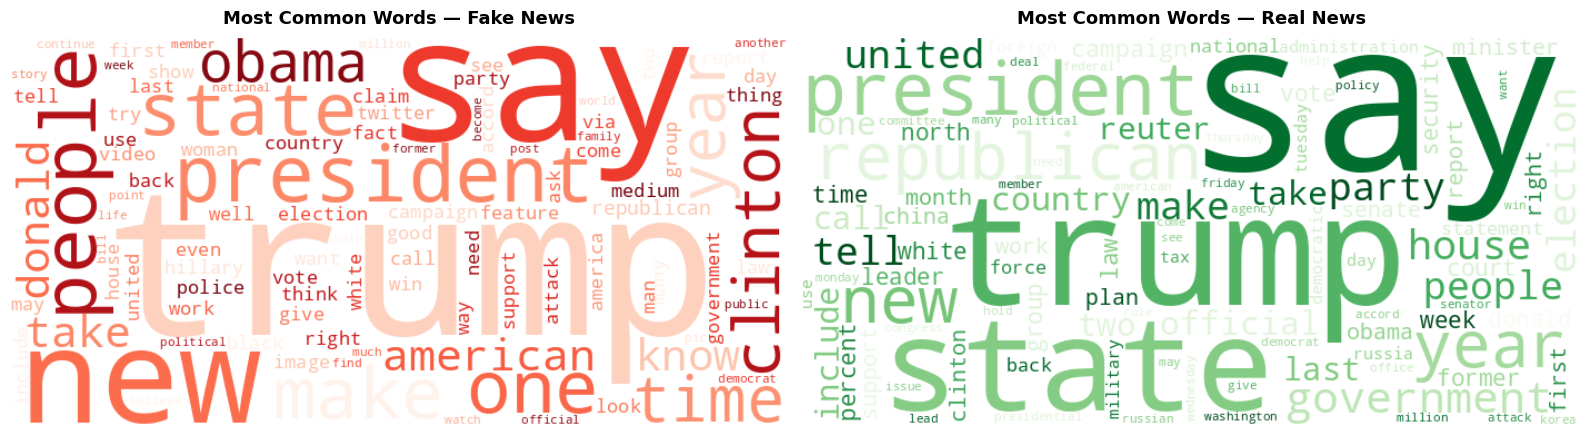

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, label, title, color in [
    (axes[0], 0, 'Most Common Words — Fake News', 'Reds'),
    (axes[1], 1, 'Most Common Words — Real News', 'Greens')
]:
    corpus = ' '.join(df[df['label'] == label]['clean_text'])
    wc = WordCloud(
        width=700, height=350,
        background_color='white',
        colormap=color,
        max_words=100,
        collocations=False
    ).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

## 7. Stratified Train / Val / Test Split

**Critical:** The split happens before vectorisation.  
Fitting the vectorizer on the full dataset would let information from val/test  
influence the vocabulary — a form of data leakage.

In [8]:
# 80% train — 10% val — 10% test, all stratified
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=RANDOM_SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

X_train_raw = train_df['clean_text'].tolist()
X_val_raw   = val_df['clean_text'].tolist()
X_test_raw  = test_df['clean_text'].tolist()

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

print(f'Train:      {len(X_train_raw):,}  (Fake: {(y_train==0).sum():,} | Real: {(y_train==1).sum():,})')
print(f'Validation: {len(X_val_raw):,}   (Fake: {(y_val==0).sum():,}   | Real: {(y_val==1).sum():,})')
print(f'Test:       {len(X_test_raw):,}   (Fake: {(y_test==0).sum():,}   | Real: {(y_test==1).sum():,})')

Train:      35,345  (Fake: 18,212 | Real: 17,133)
Validation: 4,418   (Fake: 2,277   | Real: 2,141)
Test:       4,419   (Fake: 2,277   | Real: 2,142)


## 8. Feature Extraction — BoW & TF-IDF

**Correct procedure:**
- `fit_transform` on training data only  
- `transform` (no fitting) on val and test

This ensures the vocabulary is learned only from training data.

In [9]:
# ── Shared vectorizer settings ────────────────────────────────────────────────
VECTORIZER_PARAMS = dict(
    max_features=50_000,   # cap vocabulary size
    ngram_range=(1, 2),    # unigrams + bigrams — captures "fake news", "white house" etc.
    min_df=3,              # ignore terms appearing in fewer than 3 documents (noise)
    max_df=0.95,           # ignore terms in >95% of documents (too common to be useful)
    sublinear_tf=True      # TF-IDF only: apply log(1+tf) — dampens very high frequencies
)

# ── Bag of Words ──────────────────────────────────────────────────────────────
bow_vectorizer = CountVectorizer(
    max_features=VECTORIZER_PARAMS['max_features'],
    ngram_range=VECTORIZER_PARAMS['ngram_range'],
    min_df=VECTORIZER_PARAMS['min_df'],
    max_df=VECTORIZER_PARAMS['max_df']
)
# FIT only on training data
X_train_bow = bow_vectorizer.fit_transform(X_train_raw)
# TRANSFORM (no fit) val and test
X_val_bow   = bow_vectorizer.transform(X_val_raw)
X_test_bow  = bow_vectorizer.transform(X_test_raw)

# ── TF-IDF ───────────────────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(**VECTORIZER_PARAMS)
# FIT only on training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)
# TRANSFORM (no fit) val and test
X_val_tfidf   = tfidf_vectorizer.transform(X_val_raw)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_raw)

print('=== Bag of Words ===')
print(f'  Vocabulary size : {len(bow_vectorizer.vocabulary_):,}')
print(f'  Train shape     : {X_train_bow.shape}')
print(f'  Val   shape     : {X_val_bow.shape}')
print(f'  Test  shape     : {X_test_bow.shape}')
print(f'  Sparsity        : {1 - X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1]):.4%}')

print('\n=== TF-IDF ===')
print(f'  Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,}')
print(f'  Train shape     : {X_train_tfidf.shape}')
print(f'  Val   shape     : {X_val_tfidf.shape}')
print(f'  Test  shape     : {X_test_tfidf.shape}')

=== Bag of Words ===
  Vocabulary size : 50,000
  Train shape     : (35345, 50000)
  Val   shape     : (4418, 50000)
  Test  shape     : (4419, 50000)
  Sparsity        : 99.5868%

=== TF-IDF ===
  Vocabulary size : 50,000
  Train shape     : (35345, 50000)
  Val   shape     : (4418, 50000)
  Test  shape     : (4419, 50000)


### Top Terms by TF-IDF Score

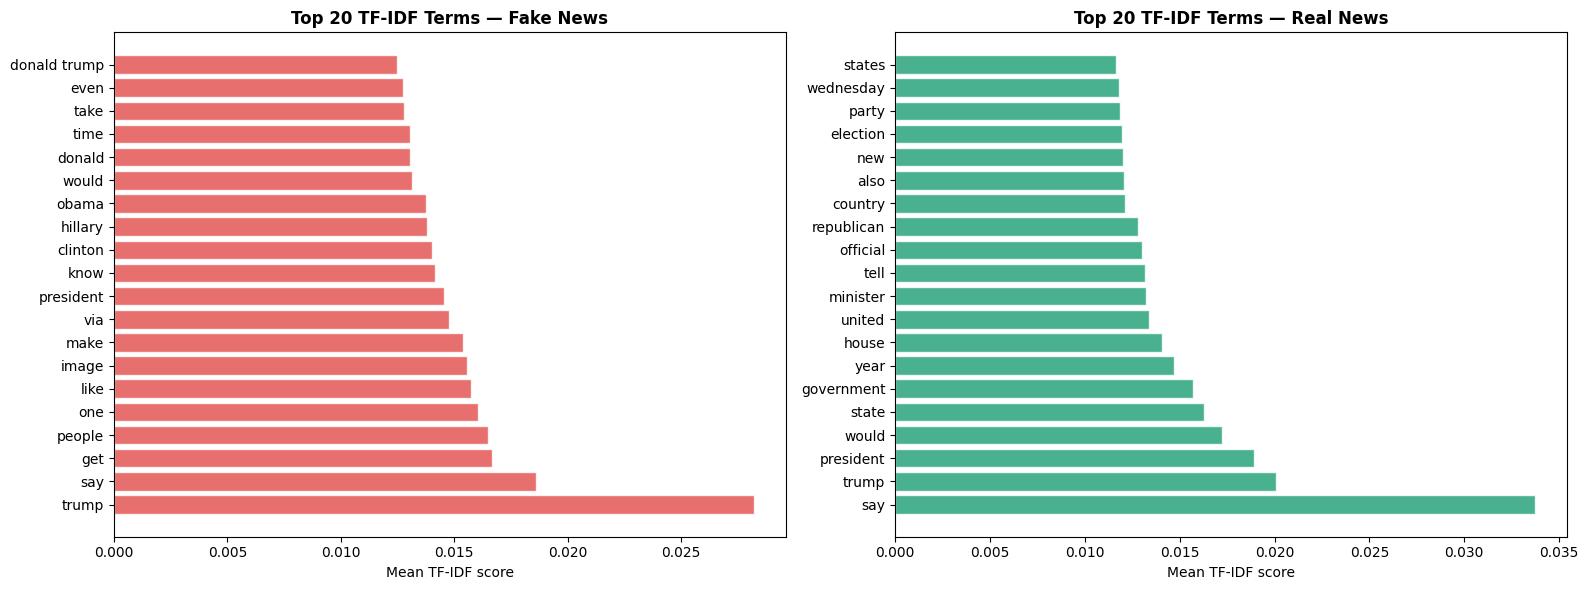

In [10]:
feature_names = tfidf_vectorizer.get_feature_names_out()
N = 20  # top N terms per class

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, title, color in [
    (axes[0], 0, f'Top {N} TF-IDF Terms — Fake News', '#E24B4A'),
    (axes[1], 1, f'Top {N} TF-IDF Terms — Real News',  '#1D9E75')
]:
    idx = (y_train == label)
    mean_tfidf = np.asarray(X_train_tfidf[idx].mean(axis=0)).flatten()
    top_idx    = mean_tfidf.argsort()[-N:][::-1]
    top_terms  = feature_names[top_idx]
    top_scores = mean_tfidf[top_idx]

    ax.barh(range(N), top_scores[::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(N))
    ax.set_yticklabels(top_terms[::-1])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF score')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Helper — Evaluation Function

In [11]:
def evaluate_model(name, y_true, y_pred, y_proba=None, verbose=True):
    """
    Compute and print a full suite of evaluation metrics.

    Args:
        name     : Model name (for display)
        y_true   : Ground-truth labels
        y_pred   : Predicted labels
        y_proba  : Predicted probabilities for class 1 (optional, needed for AUC)
        verbose  : Print full classification report

    Returns:
        dict of metrics
    """
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    mcc = matthews_corrcoef(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    if verbose:
        print(f'\n{'='*55}')
        print(f'  {name}')
        print(f'{'='*55}')
        print(f'  Accuracy  : {acc:.4f}')
        print(f'  F1 (macro): {f1:.4f}  ← primary metric')
        print(f'  Precision : {p:.4f}')
        print(f'  Recall    : {r:.4f}')
        print(f'  MCC       : {mcc:.4f}')
        if auc is not None:
            print(f'  AUC-ROC   : {auc:.4f}')
        print()
        print(classification_report(y_true, y_pred,
                                    target_names=['Fake', 'Real']))

    return {
        'name':      name,
        'accuracy':  round(acc, 4),
        'f1':        round(f1, 4),
        'precision': round(p, 4),
        'recall':    round(r, 4),
        'mcc':       round(mcc, 4),
        'auc_roc':   round(auc, 4) if auc is not None else None,
    }


def plot_confusion_matrix(y_true, y_pred, title):
    """Plot raw-count and row-normalised confusion matrices side by side."""
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, data, fmt, ttl in [
        (axes[0], cm,      'd',    f'{title} — counts'),
        (axes[1], cm_norm, '.2%',  f'{title} — normalised'),
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=['Fake','Real'],
                    yticklabels=['Fake','Real'],
                    ax=ax, linewidths=0.5)
        ax.set_title(ttl, fontweight='bold')
        ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()


print('Helper functions ready.')

Helper functions ready.


## 10. Compute Class Weights

In [12]:
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}

print(f'Class weights — Fake: {cw[0]:.4f}  |  Real: {cw[1]:.4f}')
if abs(cw[0] - cw[1]) < 0.05:
    print('Dataset is balanced — class weights are nearly equal.')
else:
    print('Dataset is imbalanced — class_weight will be applied to classifiers that support it.')

Class weights — Fake: 0.9704  |  Real: 1.0315
Dataset is imbalanced — class_weight will be applied to classifiers that support it.


## 11. Train Models

Three classifiers are trained on both BoW and TF-IDF features:

| Classifier | Notes |
|---|---|
| Logistic Regression | Strong baseline; supports `class_weight`, outputs probabilities |
| Linear SVM | Often best on high-dimensional sparse text; fast, no direct proba |
| Complement Naive Bayes | Better than Multinomial NB for imbalanced text; requires counts |

**Cross-validation strategy:** 5-fold `StratifiedKFold` inside `GridSearchCV`, scoring on F1-macro.

### 11a. Logistic Regression


--- Logistic Regression + BoW ---
  Best params : {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1  : 0.9877

  LR + BoW [Val]
  Accuracy  : 0.9876
  F1 (macro): 0.9875  ← primary metric
  Precision : 0.9875
  Recall    : 0.9875
  MCC       : 0.9751
  AUC-ROC   : 0.9974

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2277
        Real       0.99      0.99      0.99      2141

    accuracy                           0.99      4418
   macro avg       0.99      0.99      0.99      4418
weighted avg       0.99      0.99      0.99      4418


  LR + BoW [Test]
  Accuracy  : 0.9823
  F1 (macro): 0.9823  ← primary metric
  Precision : 0.9825
  Recall    : 0.9822
  MCC       : 0.9647
  AUC-ROC   : 0.9964

              precision    recall  f1-score   support

        Fake       0.98      0.99      0.98      2277
        Real       0.99      0.98      0.98      2142

    accuracy                           0.98      4419
   m

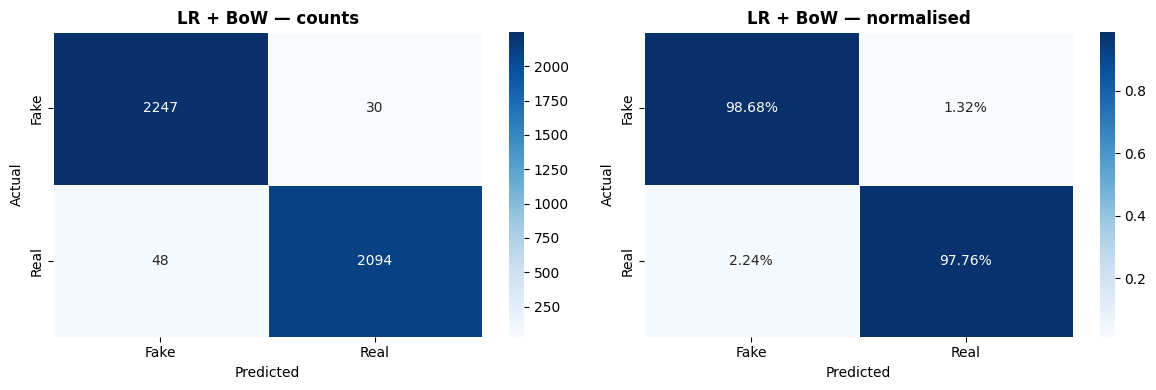


--- Logistic Regression + TF-IDF ---
  Best params : {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1  : 0.9915

  LR + TF-IDF [Val]
  Accuracy  : 0.9923
  F1 (macro): 0.9923  ← primary metric
  Precision : 0.9923
  Recall    : 0.9923
  MCC       : 0.9846
  AUC-ROC   : 0.9993

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2277
        Real       0.99      0.99      0.99      2141

    accuracy                           0.99      4418
   macro avg       0.99      0.99      0.99      4418
weighted avg       0.99      0.99      0.99      4418


  LR + TF-IDF [Test]
  Accuracy  : 0.9887
  F1 (macro): 0.9887  ← primary metric
  Precision : 0.9887
  Recall    : 0.9886
  MCC       : 0.9774
  AUC-ROC   : 0.9987

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2277
        Real       0.99      0.99      0.99      2142

    accuracy                           0.99      

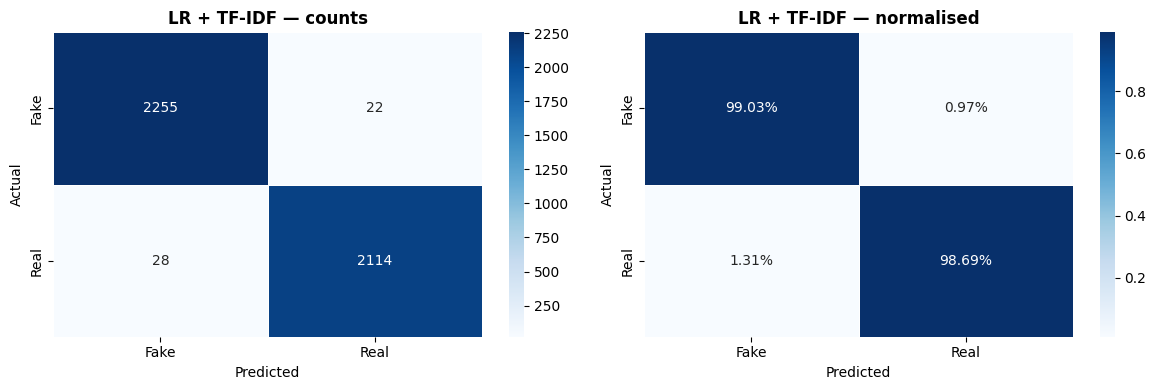

In [13]:
lr_param_grid = {
    'C':       [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

all_results = []  # will collect all model metrics for final comparison

for feat_name, X_tr, X_va, X_te in [
    ('BoW',   X_train_bow,   X_val_bow,   X_test_bow),
    ('TF-IDF',X_train_tfidf, X_val_tfidf, X_test_tfidf),
]:
    print(f'\n--- Logistic Regression + {feat_name} ---')

    lr_grid = GridSearchCV(
        LogisticRegression(max_iter=1000, class_weight='balanced'),
        lr_param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )
    lr_grid.fit(X_tr, y_train)

    print(f'  Best params : {lr_grid.best_params_}')
    print(f'  Best CV F1  : {lr_grid.best_score_:.4f}')

    best_lr = lr_grid.best_estimator_

    # Validation metrics
    val_pred  = best_lr.predict(X_va)
    val_proba = best_lr.predict_proba(X_va)[:, 1]
    val_res   = evaluate_model(f'LR + {feat_name} [Val]', y_val, val_pred, val_proba)

    # Test metrics
    test_pred  = best_lr.predict(X_te)
    test_proba = best_lr.predict_proba(X_te)[:, 1]
    test_res   = evaluate_model(f'LR + {feat_name} [Test]', y_test, test_pred, test_proba)
    all_results.append(test_res)

    plot_confusion_matrix(y_test, test_pred, f'LR + {feat_name}')

    # Store best model for each feature type
    if feat_name == 'TF-IDF':
        best_lr_tfidf  = best_lr
        lr_tfidf_proba = test_proba
        lr_tfidf_pred  = test_pred
    else:
        best_lr_bow  = best_lr
        lr_bow_proba = test_proba

### 11b. Support Vector Machine (LinearSVC)


--- LinearSVC + BoW ---


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

  Best params : {'C': 0.01, 'loss': 'squared_hinge'}
  Best CV F1  : 0.9866

  SVM + BoW [Val]
  Accuracy  : 0.9878
  F1 (macro): 0.9878  ← primary metric
  Precision : 0.9877
  Recall    : 0.9878
  MCC       : 0.9755
  AUC-ROC   : 0.9972

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2277
        Real       0.99      0.99      0.99      2141

    accuracy                           0.99      4418
   macro avg       0.99      0.99      0.99      4418
weighted avg       0.99      0.99      0.99      4418


  SVM + BoW [Test]
  Accuracy  : 0.9848
  F1 (macro): 0.9848  ← primary metric
  Precision : 0.9849
  Recall    : 0.9848
  MCC       : 0.9697
  AUC-ROC   : 0.9963

              precision    recall  f1-score   support

        Fake       0.98      0.99      0.99      2277
        Real       0.99      0.98      0.98      2142

    accuracy                           0.98      4419
   macro avg       0.98      0.98      0.98      4

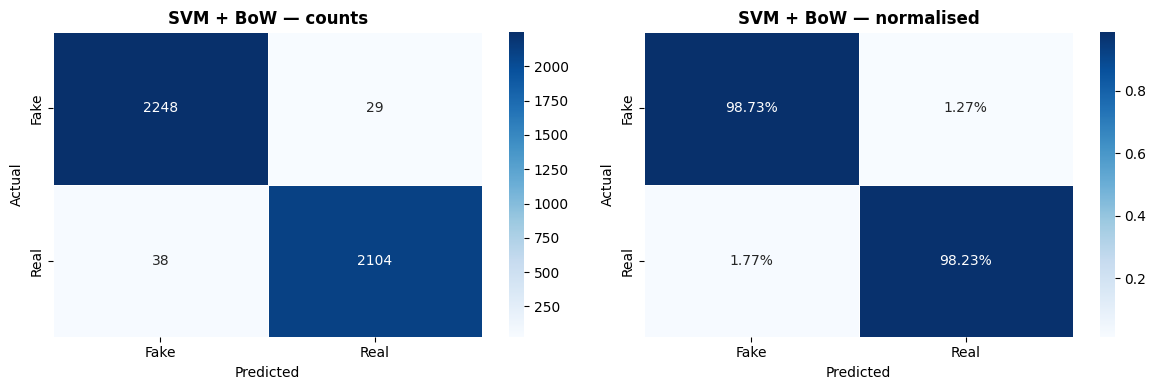


--- LinearSVC + TF-IDF ---
  Best params : {'C': 10, 'loss': 'squared_hinge'}
  Best CV F1  : 0.9927

  SVM + TF-IDF [Val]
  Accuracy  : 0.9930
  F1 (macro): 0.9930  ← primary metric
  Precision : 0.9929
  Recall    : 0.9930
  MCC       : 0.9860
  AUC-ROC   : 0.9993

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2277
        Real       0.99      0.99      0.99      2141

    accuracy                           0.99      4418
   macro avg       0.99      0.99      0.99      4418
weighted avg       0.99      0.99      0.99      4418


  SVM + TF-IDF [Test]
  Accuracy  : 0.9916
  F1 (macro): 0.9916  ← primary metric
  Precision : 0.9916
  Recall    : 0.9916
  MCC       : 0.9832
  AUC-ROC   : 0.9987

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2277
        Real       0.99      0.99      0.99      2142

    accuracy                           0.99      4419
   macro avg      

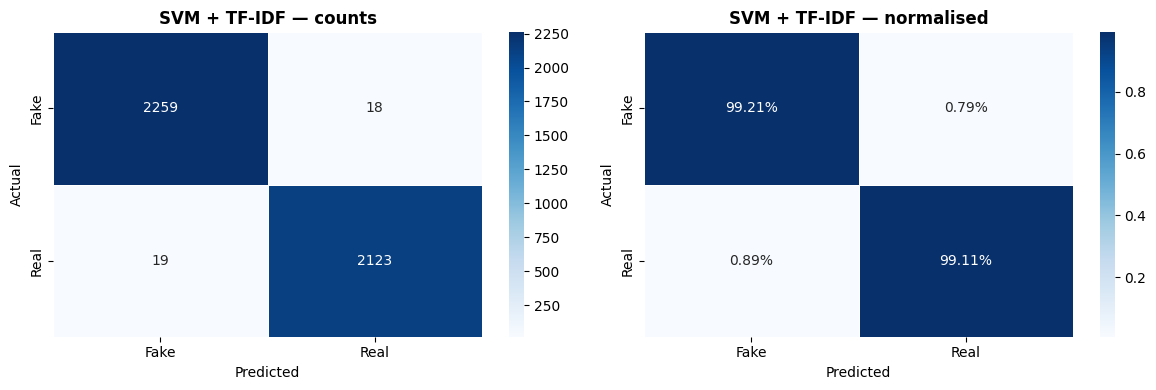

In [14]:
svm_param_grid = {
    'C':    [0.01, 0.1, 1, 10],
    'loss': ['hinge', 'squared_hinge'],
}

for feat_name, X_tr, X_va, X_te in [
    ('BoW',   X_train_bow,   X_val_bow,   X_test_bow),
    ('TF-IDF',X_train_tfidf, X_val_tfidf, X_test_tfidf),
]:
    print(f'\n--- LinearSVC + {feat_name} ---')

    svm_grid = GridSearchCV(
        LinearSVC(max_iter=2000, class_weight='balanced'),
        svm_param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )
    svm_grid.fit(X_tr, y_train)

    print(f'  Best params : {svm_grid.best_params_}')
    print(f'  Best CV F1  : {svm_grid.best_score_:.4f}')

    # LinearSVC doesn't output probabilities — use CalibratedClassifierCV
    calibrated_svm = CalibratedClassifierCV(svm_grid.best_estimator_, cv=3)
    calibrated_svm.fit(X_tr, y_train)

    # Validation
    val_pred  = calibrated_svm.predict(X_va)
    val_proba = calibrated_svm.predict_proba(X_va)[:, 1]
    evaluate_model(f'SVM + {feat_name} [Val]', y_val, val_pred, val_proba)

    # Test
    test_pred  = calibrated_svm.predict(X_te)
    test_proba = calibrated_svm.predict_proba(X_te)[:, 1]
    test_res   = evaluate_model(f'SVM + {feat_name} [Test]', y_test, test_pred, test_proba)
    all_results.append(test_res)

    plot_confusion_matrix(y_test, test_pred, f'SVM + {feat_name}')

    if feat_name == 'TF-IDF':
        best_svm_tfidf  = calibrated_svm
        svm_tfidf_proba = test_proba
        svm_tfidf_pred  = test_pred
    else:
        best_svm_bow = calibrated_svm

### 11c. Complement Naive Bayes

Naive Bayes requires **non-negative** features — compatible with BoW counts.  
TF-IDF weights are also non-negative so both work.  
**Complement NB** is used instead of Multinomial NB — it handles class imbalance better  
by modelling each class as the complement of the other.


--- Complement Naive Bayes + BoW ---
  Best alpha  : {'alpha': 0.001}
  Best CV F1  : 0.9600

  NB + BoW [Val]
  Accuracy  : 0.9602
  F1 (macro): 0.9601  ← primary metric
  Precision : 0.9601
  Recall    : 0.9602
  MCC       : 0.9203
  AUC-ROC   : 0.9820

              precision    recall  f1-score   support

        Fake       0.96      0.96      0.96      2277
        Real       0.96      0.96      0.96      2141

    accuracy                           0.96      4418
   macro avg       0.96      0.96      0.96      4418
weighted avg       0.96      0.96      0.96      4418


  NB + BoW [Test]
  Accuracy  : 0.9547
  F1 (macro): 0.9547  ← primary metric
  Precision : 0.9547
  Recall    : 0.9547
  MCC       : 0.9094
  AUC-ROC   : 0.9809

              precision    recall  f1-score   support

        Fake       0.96      0.96      0.96      2277
        Real       0.95      0.95      0.95      2142

    accuracy                           0.95      4419
   macro avg       0.95      0.95 

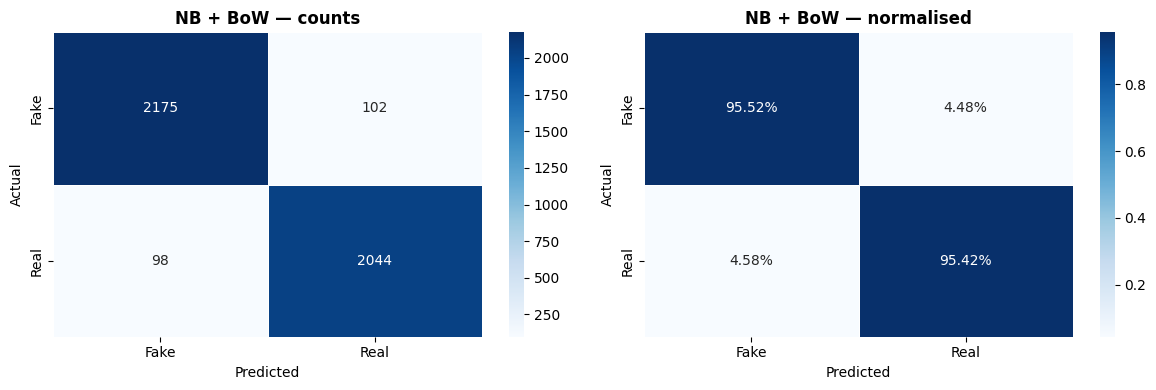


--- Complement Naive Bayes + TF-IDF ---
  Best alpha  : {'alpha': 0.001}
  Best CV F1  : 0.9598

  NB + TF-IDF [Val]
  Accuracy  : 0.9606
  F1 (macro): 0.9606  ← primary metric
  Precision : 0.9606
  Recall    : 0.9606
  MCC       : 0.9212
  AUC-ROC   : 0.9920

              precision    recall  f1-score   support

        Fake       0.96      0.96      0.96      2277
        Real       0.96      0.96      0.96      2141

    accuracy                           0.96      4418
   macro avg       0.96      0.96      0.96      4418
weighted avg       0.96      0.96      0.96      4418


  NB + TF-IDF [Test]
  Accuracy  : 0.9523
  F1 (macro): 0.9522  ← primary metric
  Precision : 0.9523
  Recall    : 0.9521
  MCC       : 0.9044
  AUC-ROC   : 0.9901

              precision    recall  f1-score   support

        Fake       0.95      0.96      0.95      2277
        Real       0.95      0.95      0.95      2142

    accuracy                           0.95      4419
   macro avg       0.95  

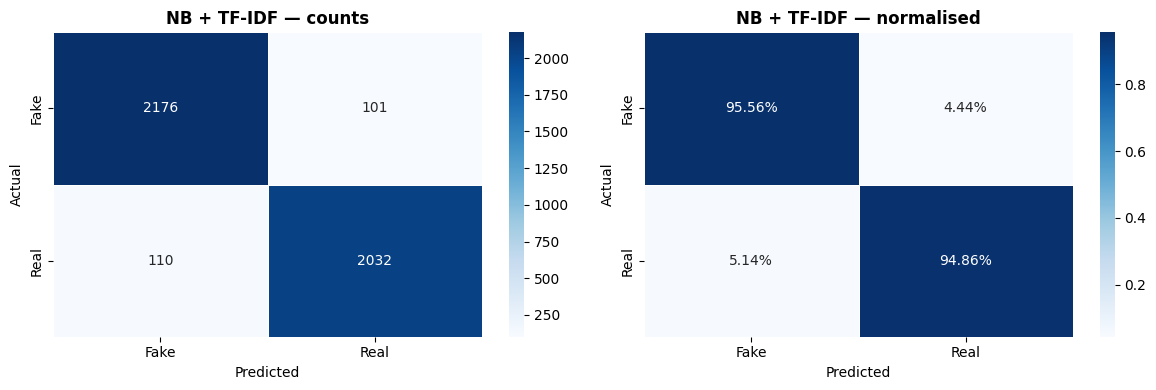

In [15]:
nb_param_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]}

for feat_name, X_tr, X_va, X_te in [
    ('BoW',   X_train_bow,   X_val_bow,   X_test_bow),
    ('TF-IDF',X_train_tfidf, X_val_tfidf, X_test_tfidf),
]:
    print(f'\n--- Complement Naive Bayes + {feat_name} ---')

    nb_grid = GridSearchCV(
        ComplementNB(),
        nb_param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )
    nb_grid.fit(X_tr, y_train)

    print(f'  Best alpha  : {nb_grid.best_params_}')
    print(f'  Best CV F1  : {nb_grid.best_score_:.4f}')

    best_nb = nb_grid.best_estimator_

    val_pred  = best_nb.predict(X_va)
    val_proba = best_nb.predict_proba(X_va)[:, 1]
    evaluate_model(f'NB + {feat_name} [Val]', y_val, val_pred, val_proba)

    test_pred  = best_nb.predict(X_te)
    test_proba = best_nb.predict_proba(X_te)[:, 1]
    test_res   = evaluate_model(f'NB + {feat_name} [Test]', y_test, test_pred, test_proba)
    all_results.append(test_res)

    plot_confusion_matrix(y_test, test_pred, f'NB + {feat_name}')

    if feat_name == 'TF-IDF':
        best_nb_tfidf  = best_nb
        nb_tfidf_proba = test_proba
        nb_tfidf_pred  = test_pred

## 12. ROC Curves — All Models

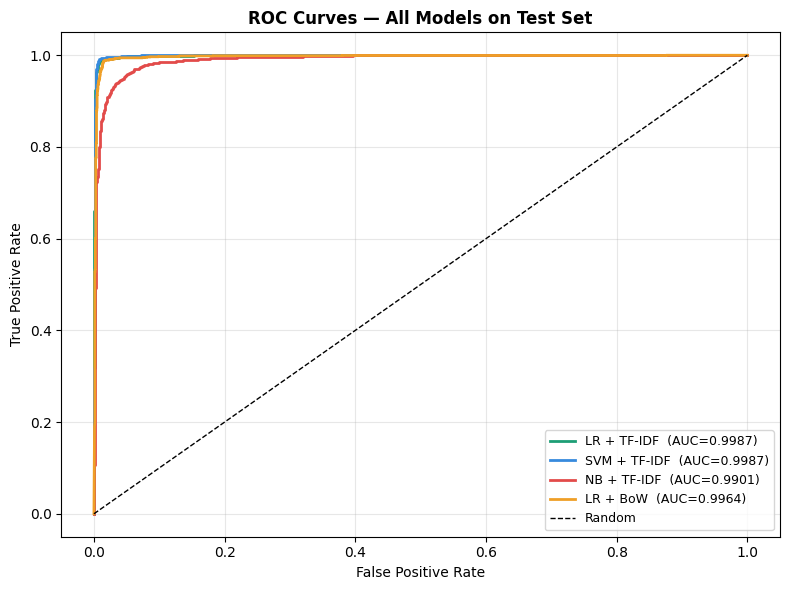

In [16]:
# Collect (name, proba) pairs for TF-IDF models (best feature set)
roc_models = [
    ('LR + TF-IDF',  lr_tfidf_proba),
    ('SVM + TF-IDF', svm_tfidf_proba),
    ('NB + TF-IDF',  nb_tfidf_proba),
    ('LR + BoW',     lr_bow_proba),
]

colors = ['#1D9E75', '#378ADD', '#E24B4A', '#EF9F27']

plt.figure(figsize=(8, 6))
for (name, proba), color in zip(roc_models, colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name}  (AUC={auc:.4f})')

plt.plot([0,1],[0,1],'k--',lw=1,label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models on Test Set', fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Model Comparison Summary

=== MODEL COMPARISON (Test Set, sorted by F1-macro) ===
                     accuracy      f1  precision  recall     mcc  auc_roc
name                                                                     
SVM + TF-IDF [Test]    0.9916  0.9916     0.9916  0.9916  0.9832   0.9987
LR + TF-IDF [Test]     0.9887  0.9887     0.9887  0.9886  0.9774   0.9987
SVM + BoW [Test]       0.9848  0.9848     0.9849  0.9848  0.9697   0.9963
LR + BoW [Test]        0.9823  0.9823     0.9825  0.9822  0.9647   0.9964
NB + BoW [Test]        0.9547  0.9547     0.9547  0.9547  0.9094   0.9809
NB + TF-IDF [Test]     0.9523  0.9522     0.9523  0.9521  0.9044   0.9901


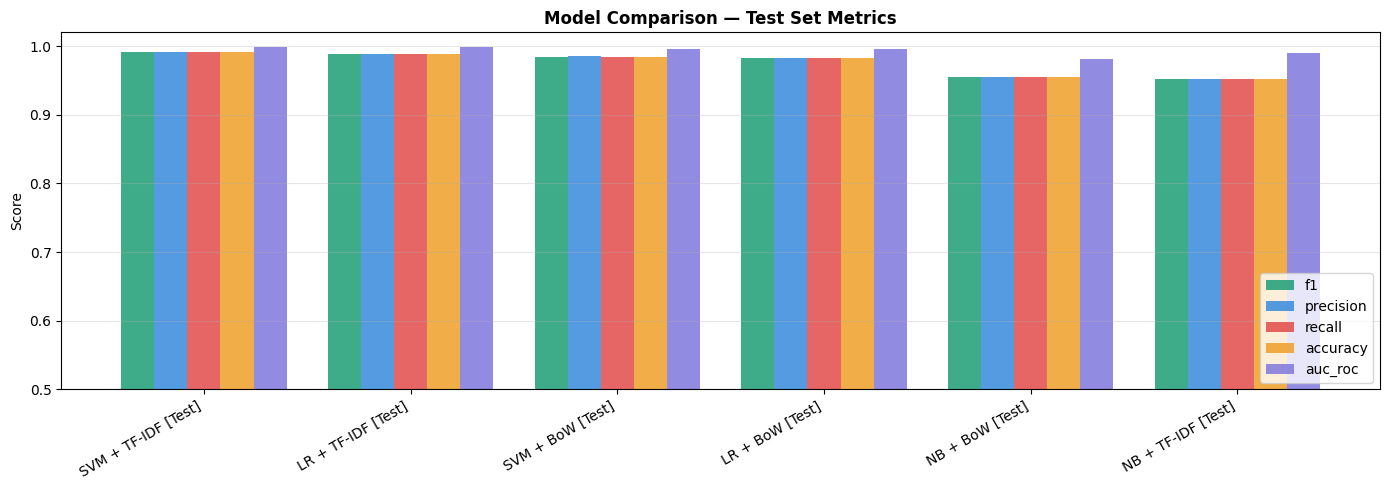


Best model: SVM + TF-IDF [Test]  (F1=0.9916)


In [17]:
results_df = pd.DataFrame(all_results).set_index('name').sort_values('f1', ascending=False)

print('=== MODEL COMPARISON (Test Set, sorted by F1-macro) ===')
print(results_df.to_string())

# Visual bar chart
metrics_to_plot = ['f1', 'precision', 'recall', 'accuracy', 'auc_roc']
results_plot = results_df[metrics_to_plot].dropna(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(results_plot))
width = 0.16
palette = ['#1D9E75', '#378ADD', '#E24B4A', '#EF9F27', '#7F77DD']

for i, (col, color) in enumerate(zip(results_plot.columns, palette)):
    ax.bar(x + i*width, results_plot[col], width, label=col, color=color, alpha=0.85)

ax.set_xticks(x + width * (len(results_plot.columns)-1)/2)
ax.set_xticklabels(results_plot.index, rotation=30, ha='right')
ax.set_ylim(0.5, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Metrics', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_model_name = results_df.index[0]
print(f'\nBest model: {best_model_name}  (F1={results_df.iloc[0]["f1"]:.4f})')

## 14. Feature Importance — Top Discriminative Words

Logistic Regression coefficients directly tell us which words push predictions  
toward Fake (negative coefficient) or Real (positive coefficient).

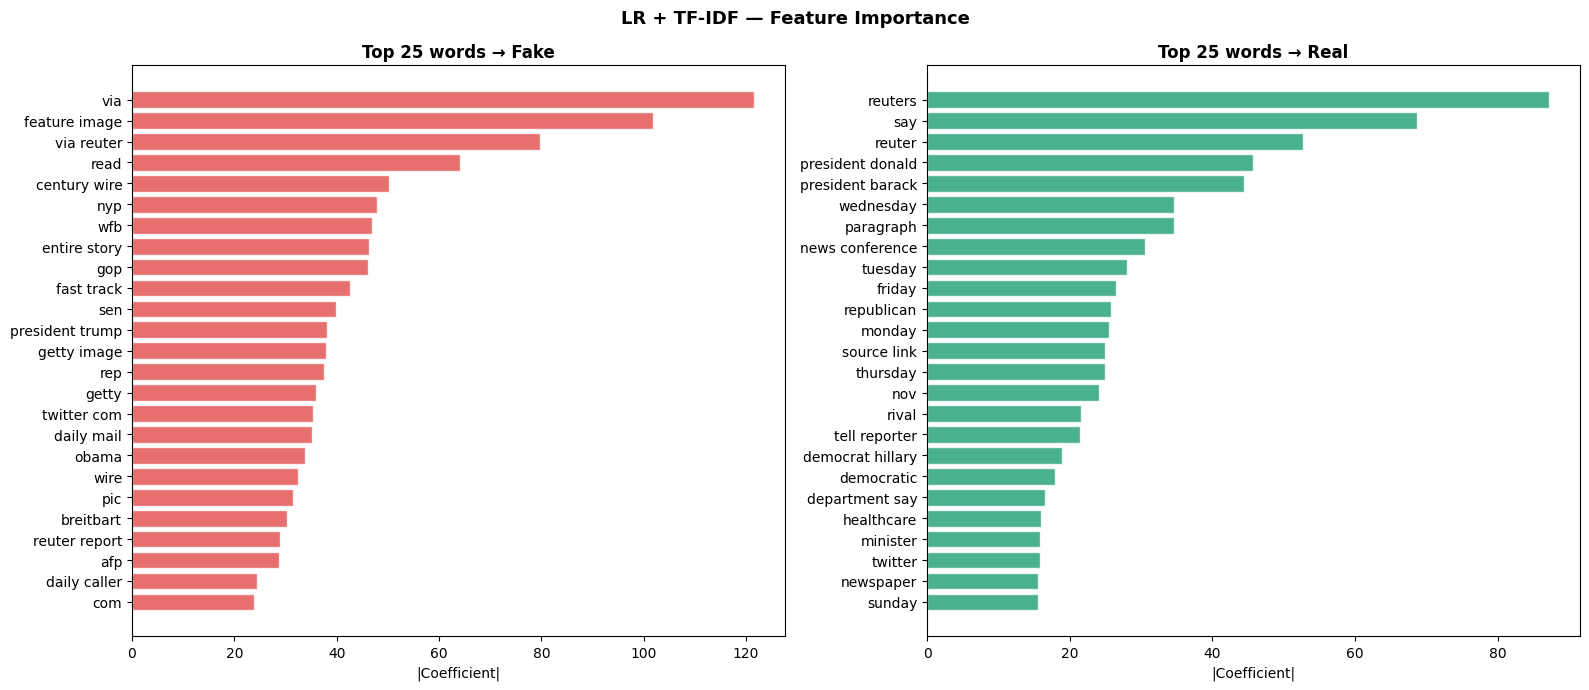

In [18]:
feat_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefs      = best_lr_tfidf.coef_[0]  # shape (n_features,)

N = 25
top_real_idx = coefs.argsort()[-N:][::-1]   # highest coef = predicts Real
top_fake_idx = coefs.argsort()[:N]           # lowest coef  = predicts Fake

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, idx, title, color in [
    (axes[0], top_fake_idx, f'Top {N} words → Fake', '#E24B4A'),
    (axes[1], top_real_idx, f'Top {N} words → Real', '#1D9E75'),
]:
    words  = feat_names[idx]
    scores = np.abs(coefs[idx])
    sort_i = scores.argsort()
    ax.barh(range(N), scores[sort_i], color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(N))
    ax.set_yticklabels(words[sort_i])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('|Coefficient|')

plt.suptitle('LR + TF-IDF — Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. BoW vs TF-IDF — Head-to-Head per Classifier

=== BoW vs TF-IDF — F1-macro on Test Set ===
features       BoW  TF-IDF  TF-IDF wins by
classifier                                
LR          0.9823  0.9887          0.0064
NB          0.9547  0.9522         -0.0025
SVM         0.9848  0.9916          0.0068


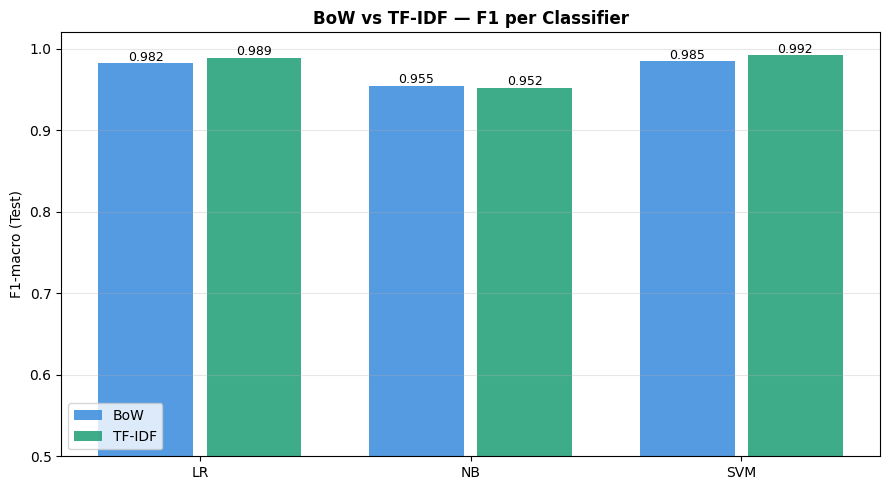

In [20]:
# Organise results into a comparison table
comparison = pd.DataFrame(all_results)

# Parse feature type and classifier name
comparison['features']   = comparison['name'].str.extract(r'\+ (\S+)')
comparison['classifier'] = (
    comparison['name']
    .str.extract(r'^([^+]+)')[0]
    .str.strip()
)
comparison['classifier'] = comparison['classifier'].str.replace(' \[Test\]','', regex=False)

pivot = comparison.pivot_table(index='classifier', columns='features', values='f1')
pivot['TF-IDF wins by'] = (pivot['TF-IDF'] - pivot['BoW']).round(4)

print('=== BoW vs TF-IDF — F1-macro on Test Set ===')
print(pivot.to_string())

# Grouped bar chart
classifiers = pivot.index.tolist()
x = np.arange(len(classifiers))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, pivot['BoW'],    0.35, label='BoW',    color='#378ADD', alpha=0.85)
ax.bar(x + 0.2, pivot['TF-IDF'],0.35, label='TF-IDF', color='#1D9E75', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(classifiers)
ax.set_ylim(0.5, 1.02)
ax.set_ylabel('F1-macro (Test)')
ax.set_title('BoW vs TF-IDF — F1 per Classifier', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate bars
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 16. Save Best Model + Vectorizer

In [21]:
import os, pickle, json
import numpy as np
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── Vectorizers ───────────────────────────────────────────────────────────────
with open(MODEL_SAVE_DIR + 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

with open(MODEL_SAVE_DIR + 'bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow_vectorizer, f)

# ── All trained models ────────────────────────────────────────────────────────
model_map = {
    'lr_tfidf':  best_lr_tfidf,
    'lr_bow':    best_lr_bow,
    'svm_tfidf': best_svm_tfidf,
    'svm_bow':   best_svm_bow,
    'nb_tfidf':  best_nb_tfidf,
}
for mname, mobj in model_map.items():
    with open(MODEL_SAVE_DIR + f'{mname}.pkl', 'wb') as f:
        pickle.dump(mobj, f)

# ── All results JSON ──────────────────────────────────────────────────────────
# Ensure all values are plain Python types (not numpy) for JSON serialisation
clean_results = [
    {k: (float(v) if isinstance(v, (float, np.floating)) else
         int(v)   if isinstance(v, (int,   np.integer))  else v)
     for k, v in r.items()}
    for r in all_results
]
with open(MODEL_SAVE_DIR + 'results.json', 'w') as f:
    json.dump(clean_results, f, indent=2)

# ── Raw predictions for each TF-IDF model (needed for exact ROC in comparison) ─
# Best LR + TF-IDF
lr_tfidf_test_pred  = best_lr_tfidf.predict(X_test_tfidf)
lr_tfidf_test_proba = best_lr_tfidf.predict_proba(X_test_tfidf)[:, 1]
np.save(MODEL_SAVE_DIR + 'y_test.npy',           y_test.astype(np.int32))
np.save(MODEL_SAVE_DIR + 'lr_tfidf_pred.npy',    lr_tfidf_test_pred.astype(np.int32))
np.save(MODEL_SAVE_DIR + 'lr_tfidf_proba.npy',   lr_tfidf_test_proba.astype(np.float32))

# Best SVM + TF-IDF
svm_tfidf_test_pred  = best_svm_tfidf.predict(X_test_tfidf)
svm_tfidf_test_proba = best_svm_tfidf.predict_proba(X_test_tfidf)[:, 1]
np.save(MODEL_SAVE_DIR + 'svm_tfidf_pred.npy',   svm_tfidf_test_pred.astype(np.int32))
np.save(MODEL_SAVE_DIR + 'svm_tfidf_proba.npy',  svm_tfidf_test_proba.astype(np.float32))

# Best NB + TF-IDF
nb_tfidf_test_pred  = best_nb_tfidf.predict(X_test_tfidf)
nb_tfidf_test_proba = best_nb_tfidf.predict_proba(X_test_tfidf)[:, 1]
np.save(MODEL_SAVE_DIR + 'nb_tfidf_pred.npy',    nb_tfidf_test_pred.astype(np.int32))
np.save(MODEL_SAVE_DIR + 'nb_tfidf_proba.npy',   nb_tfidf_test_proba.astype(np.float32))

# ── Preprocessing config (so comparison notebook can replicate it) ─────────────
preprocess_config = {
    'vectorizer':       'TF-IDF',
    'ngram_range':      [1, 2],
    'max_features':     50000,
    'min_df':           3,
    'max_df':           0.95,
    'sublinear_tf':     True,
    'lemmatization':    'spacy en_core_web_sm',
    'stopwords':        'nltk english',
    'stemming':         False,
    'train_size':       int(len(y_train)),
    'val_size':         int(len(y_val)),
    'test_size':        int(len(y_test)),
    'random_seed':      RANDOM_SEED,
}
with open(MODEL_SAVE_DIR + 'preprocess_config.json', 'w') as f:
    json.dump(preprocess_config, f, indent=2)

# ── File listing with sizes ───────────────────────────────────────────────────
print(f'All artefacts saved to: {MODEL_SAVE_DIR}')
print(f'\n{"File":<38s}  {"Size":>10s}')
print('-' * 55)
for fname in sorted(os.listdir(MODEL_SAVE_DIR)):
    fpath = MODEL_SAVE_DIR + fname
    size  = os.path.getsize(fpath)
    unit  = 'MB' if size > 1e6 else 'KB'
    val   = size / 1e6 if size > 1e6 else size / 1024
    print(f'  {fname:<36s}  {val:6.1f} {unit}')


All artefacts saved to: /kaggle/working/classical_models/

File                                          Size
-------------------------------------------------------
  bow_vectorizer.pkl                       1.6 MB
  lr_bow.pkl                             391.3 KB
  lr_tfidf.pkl                           391.3 KB
  lr_tfidf_pred.npy                       17.4 KB
  lr_tfidf_proba.npy                      17.4 KB
  nb_tfidf.pkl                             2.0 MB
  nb_tfidf_pred.npy                       17.4 KB
  nb_tfidf_proba.npy                      17.4 KB
  preprocess_config.json                   0.3 KB
  results.json                             1.0 KB
  svm_bow.pkl                              1.6 MB
  svm_tfidf.pkl                            1.6 MB
  svm_tfidf_pred.npy                      17.4 KB
  svm_tfidf_proba.npy                     17.4 KB
  tfidf_vectorizer.pkl                     2.0 MB
  y_test.npy                              17.4 KB


## 17. Sanity Check — Reload & Verify Saved Artefacts

Reloads every saved file and confirms the predictions are reproducible.

In [22]:
import pickle, json, numpy as np
from sklearn.metrics import accuracy_score, f1_score

# ── 1. Reload vectorizer ──────────────────────────────────────────────────────
with open(MODEL_SAVE_DIR + 'tfidf_vectorizer.pkl', 'rb') as f:
    rl_tfidf = pickle.load(f)
assert len(rl_tfidf.vocabulary_) > 0, 'Vectorizer vocabulary is empty'
print(f'TF-IDF vectorizer : OK  (vocab size = {len(rl_tfidf.vocabulary_):,})')

# ── 2. Reload models ──────────────────────────────────────────────────────────
with open(MODEL_SAVE_DIR + 'lr_tfidf.pkl', 'rb') as f:
    rl_lr = pickle.load(f)
print(f'LR model          : OK  (type = {type(rl_lr).__name__})')

with open(MODEL_SAVE_DIR + 'svm_tfidf.pkl', 'rb') as f:
    rl_svm = pickle.load(f)
print(f'SVM model         : OK  (type = {type(rl_svm).__name__})')

# ── 3. Reload arrays ──────────────────────────────────────────────────────────
rl_y_test   = np.load(MODEL_SAVE_DIR + 'y_test.npy')
rl_lr_proba = np.load(MODEL_SAVE_DIR + 'lr_tfidf_proba.npy')
rl_lr_pred  = np.load(MODEL_SAVE_DIR + 'lr_tfidf_pred.npy')
assert len(rl_y_test) == len(rl_lr_proba) == len(rl_lr_pred), 'Array length mismatch'
assert rl_lr_proba.min() >= 0 and rl_lr_proba.max() <= 1, 'Proba out of [0,1]'
print(f'Numpy arrays      : OK  (test_size = {len(rl_y_test):,})')

# ── 4. Reproducibility check ──────────────────────────────────────────────────
X_test_rl    = rl_tfidf.transform(test_df['clean_text'].tolist())
repro_pred   = rl_lr.predict(X_test_rl)
repro_proba  = rl_lr.predict_proba(X_test_rl)[:, 1]

pred_match   = np.array_equal(repro_pred, rl_lr_pred)
proba_match  = np.allclose(repro_proba, rl_lr_proba, atol=1e-5)
print(f'Predictions match : {"OK" if pred_match else "MISMATCH — check random seeds"}')
print(f'Probabilities match: {"OK" if proba_match else "MISMATCH — check random seeds"}')

# ── 5. Metrics from saved arrays == metrics from results.json ─────────────────
with open(MODEL_SAVE_DIR + 'results.json') as f:
    saved_results = json.load(f)

lr_saved = next(r for r in saved_results if 'LR + TF-IDF' in r['name'])
recomputed_f1 = round(f1_score(rl_y_test, rl_lr_pred, average='macro'), 4)
f1_match = abs(recomputed_f1 - lr_saved['f1']) < 0.0005
print(f'F1 consistency    : {"OK" if f1_match else "MISMATCH"}  '
      f'(saved={lr_saved["f1"]:.4f}  recomputed={recomputed_f1:.4f})')

print()
print('All saved artefacts verified. Safe to use in comparison notebook.')


TF-IDF vectorizer : OK  (vocab size = 50,000)
LR model          : OK  (type = LogisticRegression)
SVM model         : OK  (type = CalibratedClassifierCV)
Numpy arrays      : OK  (test_size = 4,419)
Predictions match : OK
Probabilities match: OK
F1 consistency    : OK  (saved=0.9887  recomputed=0.9887)

All saved artefacts verified. Safe to use in comparison notebook.


## 17. Inference — Predict a New Article

In [23]:
def predict_article(text: str,
                    vectorizer=tfidf_vectorizer,
                    model=best_lr_tfidf,
                    model_name='LR + TF-IDF'):
    """
    Predict whether a raw news article is Fake or Real.

    Args:
        text       : Raw article text — preprocessing is applied automatically.
        vectorizer : Fitted vectorizer (BoW or TF-IDF).
        model      : Fitted classifier.
        model_name : Label for display.

    Returns:
        dict with prediction, confidence, and class probabilities.
    """
    clean   = preprocess(text)
    vec     = vectorizer.transform([clean])
    pred    = model.predict(vec)[0]
    proba   = model.predict_proba(vec)[0]
    label   = 'Real' if pred == 1 else 'Fake'

    result = {
        'model':      model_name,
        'prediction': label,
        'confidence': round(float(proba[pred]) * 100, 2),
        'P(Fake)':    round(float(proba[0]) * 100, 2),
        'P(Real)':    round(float(proba[1]) * 100, 2),
    }

    print(f'Model      : {result["model"]}')
    print(f'Prediction : {result["prediction"]}')
    print(f'Confidence : {result["confidence"]:.2f}%')
    print(f'P(Fake)    : {result["P(Fake)"]:.2f}%')
    print(f'P(Real)    : {result["P(Real)"]:.2f}%')

    return result


# ── Demo ──────────────────────────────────────────────────────────────────────
demo_text = """
Scientists have confirmed a new vaccine candidate shows over 90 percent efficacy
in phase 3 trials, according to peer-reviewed results published in the Lancet.
The trial involved 30,000 participants across 12 countries and was independently verified.
"""

print('=== Demo Prediction ===')
_ = predict_article(demo_text)

=== Demo Prediction ===
Model      : LR + TF-IDF
Prediction : Real
Confidence : 65.63%
P(Fake)    : 34.37%
P(Real)    : 65.63%


## 18. Load Saved Models (for future use without retraining)

In [24]:
# Run this cell any time to restore models without retraining

import pickle

with open(MODEL_SAVE_DIR + 'tfidf_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

with open(MODEL_SAVE_DIR + 'lr_tfidf.pkl', 'rb') as f:
    loaded_lr = pickle.load(f)

print('Models loaded successfully.')
print('Usage: predict_article(text, vectorizer=loaded_tfidf, model=loaded_lr)')

Models loaded successfully.
Usage: predict_article(text, vectorizer=loaded_tfidf, model=loaded_lr)


## 19. N-gram Analysis — Top Unigrams vs Bigrams

Bigrams capture context that single words miss: `white house`, `fake news`,
`breaking news` carry very different signals than their component words alone.

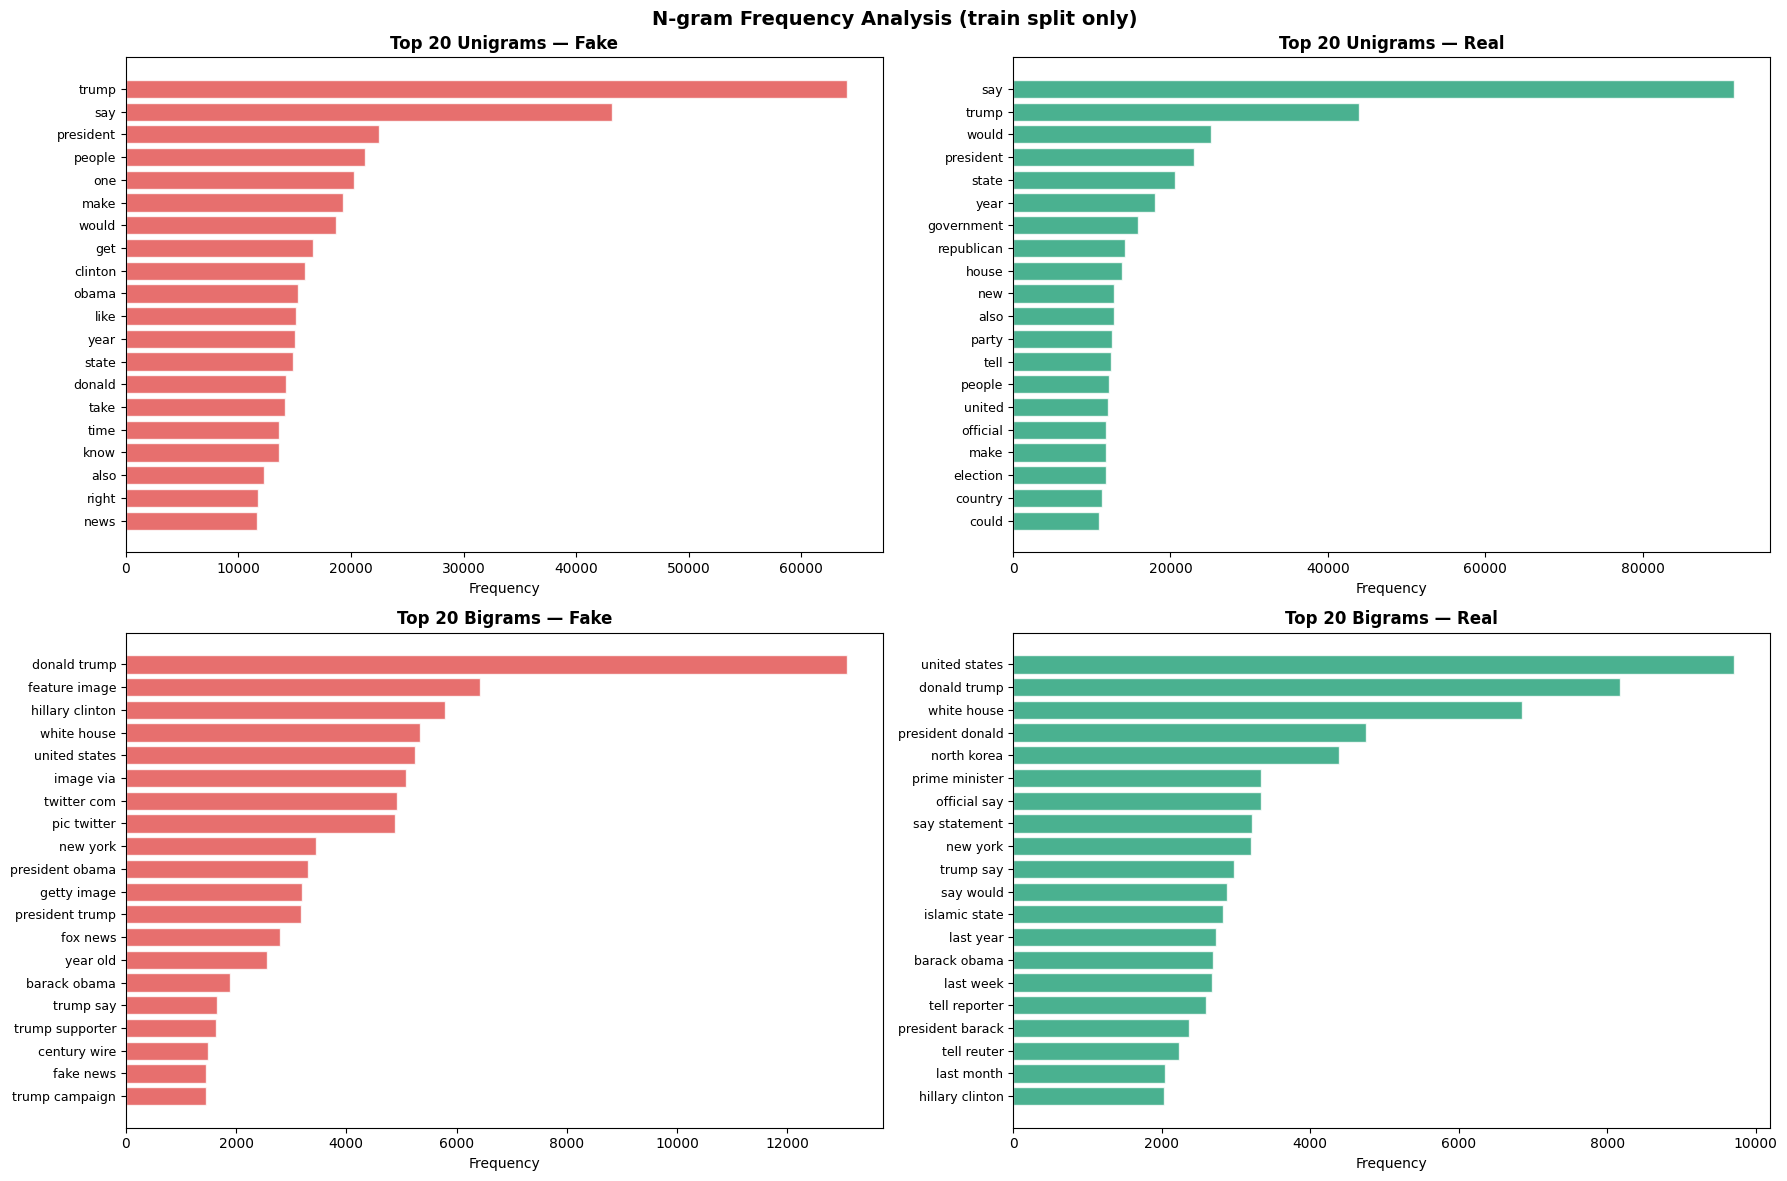

In [25]:
from collections import Counter

def top_ngrams(corpus_series, n, top_k=20):
    """Return the top_k most frequent n-grams across all texts in corpus_series."""
    from sklearn.feature_extraction.text import CountVectorizer
    vec = CountVectorizer(ngram_range=(n, n), max_features=50_000, min_df=2)
    X   = vec.fit_transform(corpus_series)
    counts = np.asarray(X.sum(axis=0)).flatten()
    top_idx = counts.argsort()[-top_k:][::-1]
    terms   = np.array(vec.get_feature_names_out())[top_idx]
    freqs   = counts[top_idx]
    return terms, freqs


fig, axes = plt.subplots(2, 2, figsize=(18, 12))

configs = [
    (0, 'Fake', 1, 'Top 20 Unigrams — Fake', '#E24B4A'),
    (1, 'Real', 1, 'Top 20 Unigrams — Real', '#1D9E75'),
    (0, 'Fake', 2, 'Top 20 Bigrams — Fake',  '#E24B4A'),
    (1, 'Real', 2, 'Top 20 Bigrams — Real',  '#1D9E75'),
]

for ax, (label, lname, n, title, color) in zip(axes.flatten(), configs):
    corpus = train_df[train_df['label'] == label]['clean_text']
    terms, freqs = top_ngrams(corpus, n, top_k=20)
    sort_i = freqs.argsort()
    ax.barh(range(20), freqs[sort_i], color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(20))
    ax.set_yticklabels(terms[sort_i], fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('N-gram Frequency Analysis (train split only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 20. Learning Curves

Learning curves show whether a model is underfitting or overfitting by plotting
train vs validation F1 as training set size grows.

- **Gap between train and val** → overfitting → try regularisation or more data  
- **Both scores plateau low** → underfitting → try richer features or a stronger model

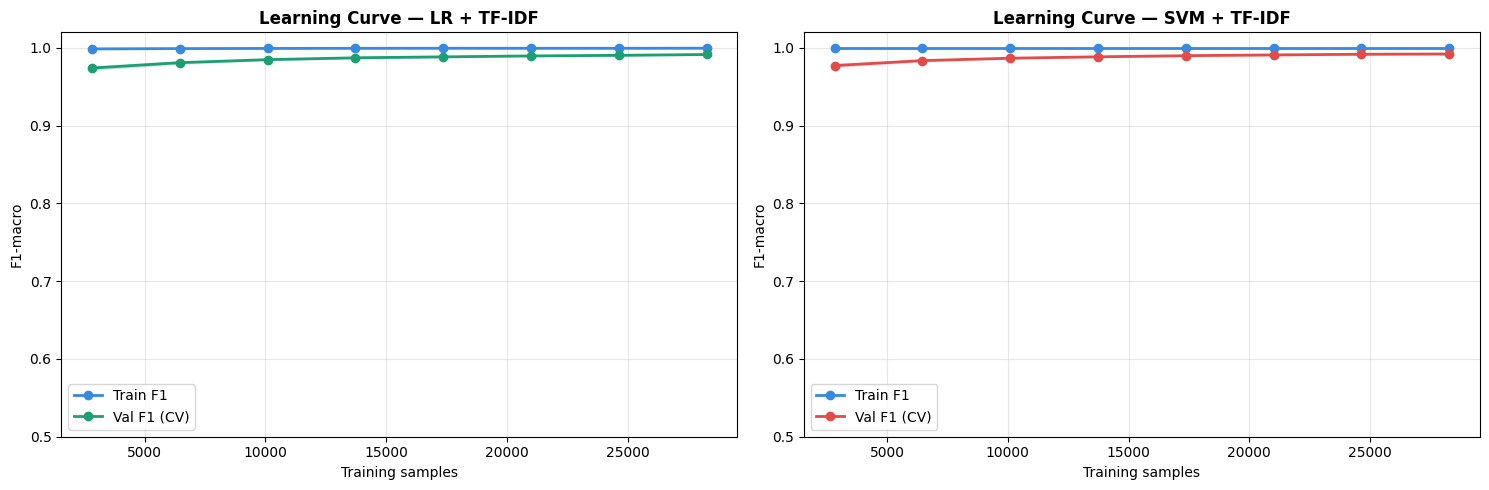

In [26]:
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 8)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# LR + TF-IDF
train_sz, train_scores, val_scores = learning_curve(
    best_lr_tfidf, X_train_tfidf, y_train,
    train_sizes=train_sizes,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_macro',
    n_jobs=-1
)

for ax, (sz, tr_sc, va_sc, title) in zip(axes, [
    (train_sz, train_scores, val_scores, 'LR + TF-IDF'),
]):
    tr_mean, tr_std = tr_sc.mean(1), tr_sc.std(1)
    va_mean, va_std = va_sc.mean(1), va_sc.std(1)

    ax.plot(sz, tr_mean, 'o-', color='#378ADD', lw=2, label='Train F1')
    ax.fill_between(sz, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='#378ADD')
    ax.plot(sz, va_mean, 'o-', color='#1D9E75', lw=2, label='Val F1 (CV)')
    ax.fill_between(sz, va_mean-va_std, va_mean+va_std, alpha=0.15, color='#1D9E75')

    ax.set_title(f'Learning Curve — {title}', fontweight='bold')
    ax.set_xlabel('Training samples')
    ax.set_ylabel('F1-macro')
    ax.set_ylim(0.5, 1.02)
    ax.legend()
    ax.grid(alpha=0.3)

# SVM + TF-IDF (second subplot)
train_sz2, train_scores2, val_scores2 = learning_curve(
    best_svm_tfidf, X_train_tfidf, y_train,
    train_sizes=train_sizes,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_macro',
    n_jobs=-1
)

tr_mean2, tr_std2 = train_scores2.mean(1), train_scores2.std(1)
va_mean2, va_std2 = val_scores2.mean(1),   val_scores2.std(1)

axes[1].plot(train_sz2, tr_mean2, 'o-', color='#378ADD', lw=2, label='Train F1')
axes[1].fill_between(train_sz2, tr_mean2-tr_std2, tr_mean2+tr_std2, alpha=0.15, color='#378ADD')
axes[1].plot(train_sz2, va_mean2, 'o-', color='#E24B4A', lw=2, label='Val F1 (CV)')
axes[1].fill_between(train_sz2, va_mean2-va_std2, va_mean2+va_std2, alpha=0.15, color='#E24B4A')
axes[1].set_title('Learning Curve — SVM + TF-IDF', fontweight='bold')
axes[1].set_xlabel('Training samples')
axes[1].set_ylabel('F1-macro')
axes[1].set_ylim(0.5, 1.02)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 21. Error Analysis — What Did the Model Get Wrong?

Inspecting misclassified articles reveals systematic patterns —
e.g. fake articles written in a neutral journalistic tone, or real articles
using sensational language — that metrics alone cannot surface.

In [27]:
# Use LR + TF-IDF predictions on the test set
test_pred_lr  = best_lr_tfidf.predict(X_test_tfidf)
test_proba_lr = best_lr_tfidf.predict_proba(X_test_tfidf)[:, 1]

error_df = test_df.copy()
error_df['predicted'] = test_pred_lr
error_df['P(Real)']   = test_proba_lr
error_df['correct']   = error_df['label'] == error_df['predicted']

# False Positives: Fake articles predicted as Real
fp = error_df[(error_df['label'] == 0) & (error_df['predicted'] == 1)].sort_values('P(Real)', ascending=False)
# False Negatives: Real articles predicted as Fake
fn = error_df[(error_df['label'] == 1) & (error_df['predicted'] == 0)].sort_values('P(Real)', ascending=True)

print(f'Total misclassifications : {(~error_df["correct"]).sum()}')
print(f'False Positives (Fake → Real predicted) : {len(fp)}')
print(f'False Negatives (Real → Fake predicted) : {len(fn)}')

print('\n' + '='*65)
print('MOST CONFIDENTLY WRONG — False Positives (Fake called Real)')
print('='*65)
for i, (_, row) in enumerate(fp.head(3).iterrows()):
    print(f'\n[FP #{i+1}]  P(Real)={row["P(Real)"]:.3f}')
    print(f'Text: {row["clean_text"][:300]}...')

print('\n' + '='*65)
print('MOST CONFIDENTLY WRONG — False Negatives (Real called Fake)')
print('='*65)
for i, (_, row) in enumerate(fn.head(3).iterrows()):
    print(f'\n[FN #{i+1}]  P(Real)={row["P(Real)"]:.3f}')
    print(f'Text: {row["clean_text"][:300]}...')

Total misclassifications : 50
False Positives (Fake → Real predicted) : 22
False Negatives (Real → Fake predicted) : 28

MOST CONFIDENTLY WRONG — False Positives (Fake called Real)

[FP #1]  P(Real)=0.999
Text: north korea say monday successfully conduct newly develop mid long range missile test sunday supervise leader kim jong aim verify capability carry large scale heavy nuclear warhead kim accuse united states browbeat country nuke warn washington misjudge reality mainland north sighting range strike no...

[FP #2]  P(Real)=0.999
Text: north korea say monday successfully conduct newly develop mid long range missile test sunday supervise leader kim jong aim verify capability carry large scale heavy nuclear warhead kim accuse united states browbeat country nuke warn washington misjudge reality mainland north sighting range strike no...

[FP #3]  P(Real)=0.998
Text: scene confrontation late friday also appear video upload social medium capture attention venezuelan many blame unpopular 

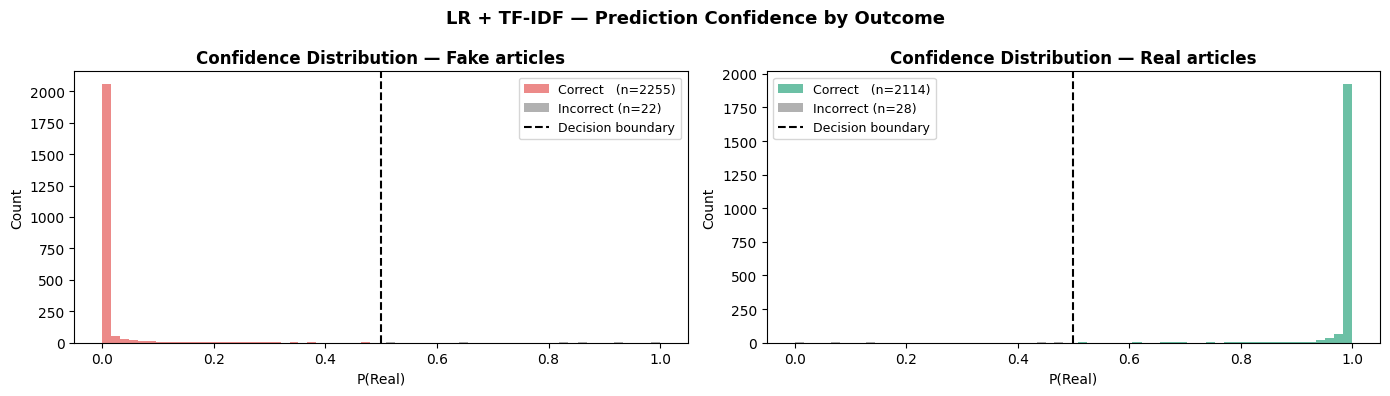

In [28]:
# ── Confidence distribution: correct vs incorrect predictions ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, label, lname, color in [
    (axes[0], 0, 'Fake articles', '#E24B4A'),
    (axes[1], 1, 'Real articles', '#1D9E75'),
]:
    subset = error_df[error_df['label'] == label]
    correct   = subset[subset['correct']]['P(Real)']
    incorrect = subset[~subset['correct']]['P(Real)']

    ax.hist(correct,   bins=30, alpha=0.65, color=color,    label=f'Correct   (n={len(correct)})')
    ax.hist(incorrect, bins=30, alpha=0.65, color='#888888',label=f'Incorrect (n={len(incorrect)})')
    ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Decision boundary')
    ax.set_title(f'Confidence Distribution — {lname}', fontweight='bold')
    ax.set_xlabel('P(Real)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('LR + TF-IDF — Prediction Confidence by Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 22. Cross-Validation Stability Check

A model that scores 0.97 on one fold but 0.82 on another is unstable.
Plotting all fold scores (not just the mean) reveals this.

LR + TF-IDF           mean=0.9915  std=0.0005  folds=[0.9911 0.9918 0.9924 0.9911 0.9912]
SVM + TF-IDF          mean=0.9922  std=0.0006  folds=[0.9914 0.9919 0.9929 0.9928 0.9918]
NB + TF-IDF           mean=0.9598  std=0.0017  folds=[0.9584 0.9578 0.9608 0.9626 0.9594]
LR + BoW              mean=0.9870  std=0.0013  folds=[0.9861 0.9887 0.9884 0.9854 0.9865]


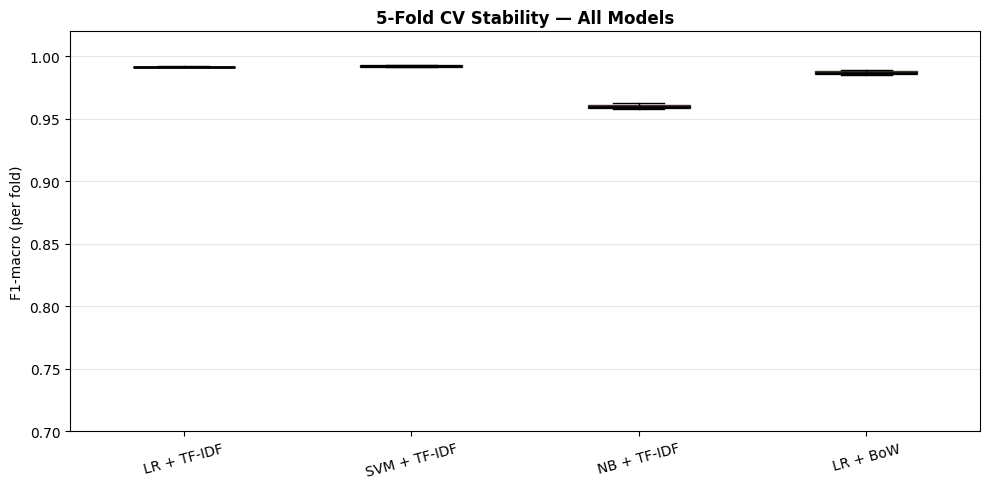

In [29]:
from sklearn.model_selection import cross_val_score

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

stability_results = {}
for name, model, X in [
    ('LR + TF-IDF',  best_lr_tfidf,  X_train_tfidf),
    ('SVM + TF-IDF', best_svm_tfidf, X_train_tfidf),
    ('NB + TF-IDF',  best_nb_tfidf,  X_train_tfidf),
    ('LR + BoW',     best_lr_bow,    X_train_bow),
]:
    scores = cross_val_score(model, X, y_train, cv=cv5, scoring='f1_macro', n_jobs=-1)
    stability_results[name] = scores
    print(f'{name:20s}  mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores, 4)}')

# Box plot of fold scores
fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    [stability_results[k] for k in stability_results],
    labels=list(stability_results.keys()),
    patch_artist=True,
    medianprops=dict(color='black', lw=2)
)
colors = ['#1D9E75', '#378ADD', '#E24B4A', '#EF9F27']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel('F1-macro (per fold)')
ax.set_title('5-Fold CV Stability — All Models', fontweight='bold')
ax.set_ylim(0.7, 1.02)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 23. Decision Threshold Tuning

The default classification threshold is 0.5, but for fake news detection
you may want to shift it:

- **Lower threshold (e.g. 0.3)** → catch more fake news (higher recall for Fake) but more false alarms
- **Higher threshold (e.g. 0.7)** → only flag when very confident; fewer false alarms but miss some fake news

The F1 curve shows the optimal threshold.

Default threshold (0.50)  F1 = 0.9887
Optimal threshold (0.48)  F1 = 0.9891


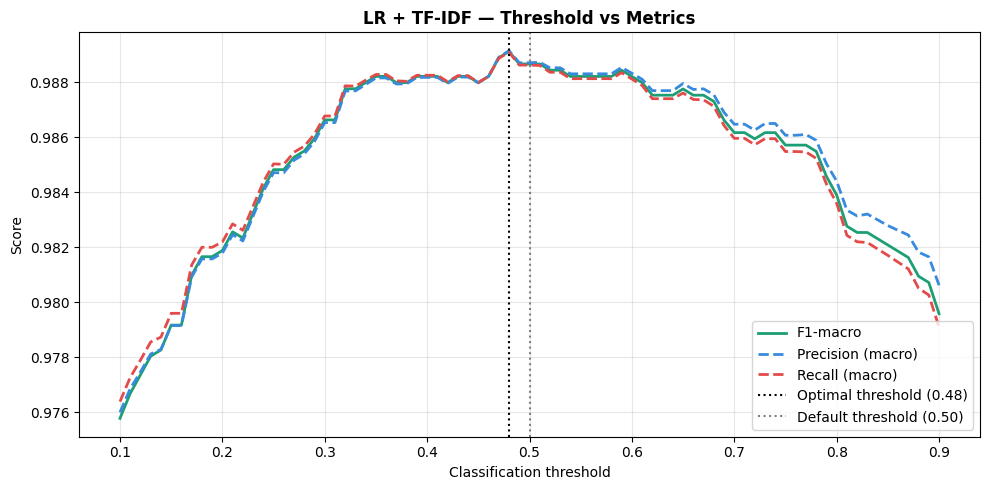

In [30]:
from sklearn.metrics import precision_recall_curve, f1_score

proba_real = best_lr_tfidf.predict_proba(X_test_tfidf)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)
f1_scores, prec_scores, rec_scores = [], [], []

for t in thresholds:
    preds = (proba_real >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds, average='macro', zero_division=0))
    p, r, _, _ = precision_recall_fscore_support(y_test, preds, average='macro', zero_division=0)
    prec_scores.append(p)
    rec_scores.append(r)

best_thresh_idx = np.argmax(f1_scores)
best_thresh     = thresholds[best_thresh_idx]
best_f1         = f1_scores[best_thresh_idx]

print(f'Default threshold (0.50)  F1 = {f1_score(y_test, (proba_real>=0.50).astype(int), average="macro"):.4f}')
print(f'Optimal threshold ({best_thresh:.2f})  F1 = {best_f1:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores,   lw=2, color='#1D9E75', label='F1-macro')
ax.plot(thresholds, prec_scores, lw=2, color='#378ADD', label='Precision (macro)', linestyle='--')
ax.plot(thresholds, rec_scores,  lw=2, color='#E24B4A', label='Recall (macro)',    linestyle='--')
ax.axvline(best_thresh, color='black', linestyle=':', lw=1.5, label=f'Optimal threshold ({best_thresh:.2f})')
ax.axvline(0.50,        color='gray',  linestyle=':', lw=1.5, label='Default threshold (0.50)')
ax.set_xlabel('Classification threshold')
ax.set_ylabel('Score')
ax.set_title('LR + TF-IDF — Threshold vs Metrics', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 24. Precision-Recall Curve

The PR curve is more informative than ROC when classes are imbalanced.
A high Area Under PR Curve (AUPRC) means the model is both precise
and comprehensive — it catches fake news without too many false alarms.

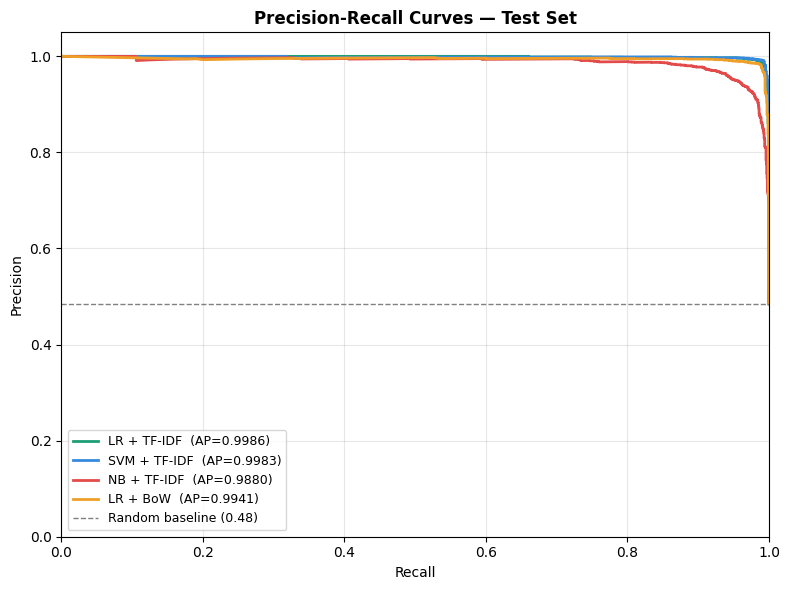

In [31]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))

pr_models = [
    ('LR + TF-IDF',  lr_tfidf_proba,  '#1D9E75'),
    ('SVM + TF-IDF', svm_tfidf_proba, '#378ADD'),
    ('NB + TF-IDF',  nb_tfidf_proba,  '#E24B4A'),
    ('LR + BoW',     lr_bow_proba,    '#EF9F27'),
]

for name, proba, color in pr_models:
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(recall_vals, precision_vals, lw=2, color=color, label=f'{name}  (AP={ap:.4f})')

# Baseline: random classifier
baseline = y_test.sum() / len(y_test)
ax.axhline(baseline, color='gray', linestyle='--', lw=1, label=f'Random baseline ({baseline:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Test Set', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 25. Final Summary — All Models

Complete metric table for all BoW and TF-IDF models on the held-out test set.

In [32]:
summary = pd.DataFrame(all_results).sort_values('f1', ascending=False)
summary = summary.rename(columns={
    'name':      'Model',
    'accuracy':  'Accuracy',
    'f1':        'F1 (macro)',
    'precision': 'Precision',
    'recall':    'Recall',
    'mcc':       'MCC',
    'auc_roc':   'AUC-ROC'
})
summary = summary.set_index('Model')

# Highlight best value in each column
styled = (summary.style
    .highlight_max(axis=0, color='#c8f0d8')
    .format('{:.4f}')
    .set_caption('Test Set Results — All Models (green = best per metric)'))

print('=== FINAL SUMMARY TABLE ===')
display(styled)

best = summary.index[0]
print(f'\nRecommendation:')
print(f'  Best classical model : {best}')
print(f'  F1-macro             : {summary.loc[best, "F1 (macro)"]:.4f}')
print(f'  AUC-ROC              : {summary.loc[best, "AUC-ROC"]:.4f}')
print()
print('Next step: compare these results against fine-tuned BERT (see BERT notebook)')
print('Expected: BERT typically achieves F1 > 0.98 on ISOT with sufficient data.')

=== FINAL SUMMARY TABLE ===


,Accuracy,F1 (macro),Precision,Recall,MCC,AUC-ROC
Model,,,,,,
SVM + TF-IDF [Test],0.9916,0.9916,0.9916,0.9916,0.9832,0.9987
LR + TF-IDF [Test],0.9887,0.9887,0.9887,0.9886,0.9774,0.9987
SVM + BoW [Test],0.9848,0.9848,0.9849,0.9848,0.9697,0.9963
LR + BoW [Test],0.9823,0.9823,0.9825,0.9822,0.9647,0.9964
NB + BoW [Test],0.9547,0.9547,0.9547,0.9547,0.9094,0.9809
NB + TF-IDF [Test],0.9523,0.9522,0.9523,0.9521,0.9044,0.9901



Recommendation:
  Best classical model : SVM + TF-IDF [Test]
  F1-macro             : 0.9916
  AUC-ROC              : 0.9987

Next step: compare these results against fine-tuned BERT (see BERT notebook)
Expected: BERT typically achieves F1 > 0.98 on ISOT with sufficient data.


## 26. When to Use BoW / TF-IDF vs BERT

| Factor | BoW | TF-IDF | BERT |
|---|---|---|---|
| Training time | Seconds | Seconds | Minutes–Hours (GPU) |
| Inference speed | Very fast | Very fast | Slower |
| Captures word order | ✗ | ✗ | ✓ |
| Captures context | ✗ | ✗ | ✓ |
| Handles unseen words | ✗ (OOV) | ✗ (OOV) | ✓ (subword) |
| Explainability | Easy (coefficients) | Easy (coefficients) | Needs LIME/SHAP |
| Data needed | ~1k samples OK | ~1k samples OK | ~5k+ recommended |
| Expected F1 on ISOT | 0.92–0.96 | 0.94–0.97 | 0.97–0.99 |

**Practical advice:**
- Always build TF-IDF + LR first — it's the fastest way to get a strong baseline
- Use BERT when you need maximum accuracy or the articles are stylistically complex
- If deploying to a resource-constrained environment, TF-IDF + SVM is the best balance